# Intelligent Methods for Resilience: Household Energy Shifting in DK1

#### Problem
The DK1 electricity system is increasingly challenged by the combination of rising electricity demand and a growing share of variable renewable energy. Electrification of transport and heating increases overall consumption, while wind and solar introduce greater temporal variability in supply. This creates periods where the system experiences peak pressure, defined by high demand relative to available supply, which can lead to congestion, inefficient use of renewable energy, and reduced system stability. At the same time, a portion of household electricity consumption is inherently flexible, meaning it can be shifted in time without significant loss of utility. The core challenge is therefore not only technological, but behavioral and informational: **how to activate this latent flexibility in a way that meaningfully supports system resilience.**

#### Question
**How can price forecasting and explainable energy recommendations be used to reduce peak pressure and improve resilience in the DK1 electricity system?**

#### Method
The project combines XGBoost-based electricity price forecasting with uncertainty intervals and explainable AI methods, and translates these forecasts into actionable household recommendations, where behavior is modelled through a 120-hour rolling shifting heuristic to evaluate the resulting resilience impact.

#### Underlying idea
The central idea is that price signals can act as a proxy for grid stress, and that translating these signals into clear, explainable recommendations enables households to shift flexible consumption away from high-pressure periods. This includes activities such as electric vehicle charging and the use of appliances like dishwashers, washing machines, and dryers, which can be delayed or advanced in time. While the impact of a single household is small, coordinated shifts across many households can aggregate into a measurable system-level effect. **The approach therefore tests whether many small, local decisions, guided by intelligent methods, can collectively improve system resilience.**


## Introduction: Defining Resilience and the Current Grid State in DK1

To evaluate whether the project improves resilience, we first need to describe the current state of the DK1 electricity grid. In this project, the most direct observable signal of grid state is electricity consumption. When consumption is high, more electricity has to be transported through the network at the same time, which increases operational pressure and makes balancing the system more difficult.

Because we do not observe transformer limits or line-level congestion directly, we use historical system consumption as a transparent proxy for stress. The first figure below plots the full historic hourly DK1 consumption series in grey and marks the historical 95th percentile with a red horizontal line. Hours around and above this threshold are treated as peak-load periods. These peaks matter because they reflect moments where the grid operates closer to its upper normal range, increasing the risk of congestion, higher balancing pressure, and faster wear on network assets.


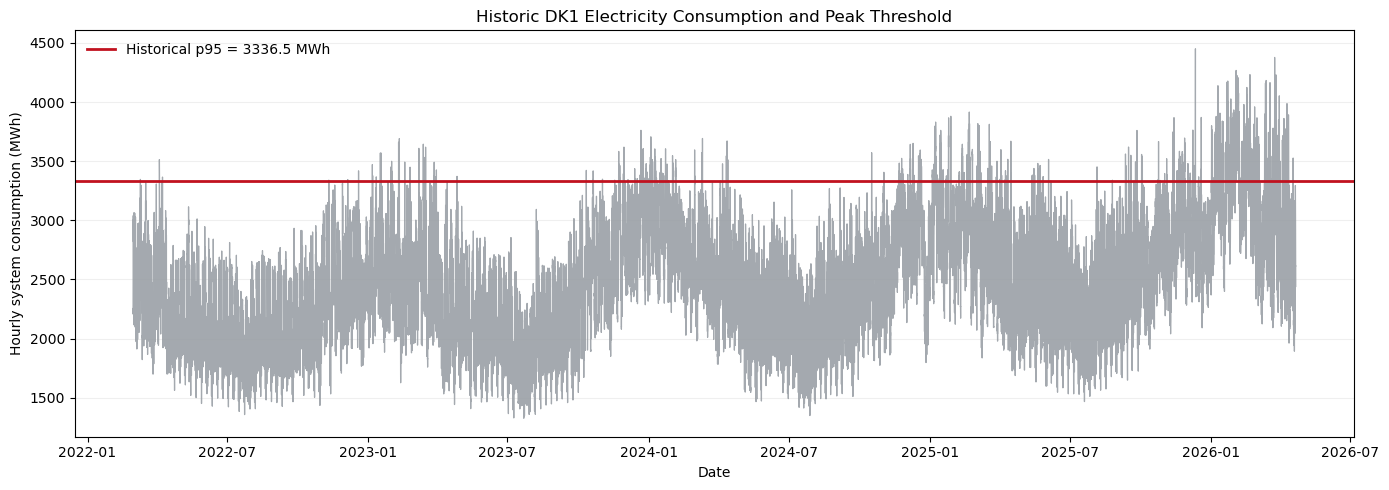

In [2]:
from src.analysis.energy_congestion_analysis import (
    build_grid_state_summary,
    plot_historic_consumption_with_p95,
)

grid_state = build_grid_state_summary()
historic_consumption_figure, _ = plot_historic_consumption_with_p95(grid_state)


The historic series shows that high-load periods are recurring rather than isolated events. It also illustrates how the consumption is increasing over the years, causing more stress hours. To understand the historic consumption trend over the years, the next figure aggregates consumption to monthly totals across the observed years and then counts how many hours in each year exceed the historical 95th percentile.

The monthly bars make the longer-run demand development easier to read than the raw hourly series. The yearly peak-hour bar chart then serves as a compact snapshot of the current grid state: if total consumption and the number of peak hours both rise over time, the need for action that removes or shifts peak loads becomes more urgent.


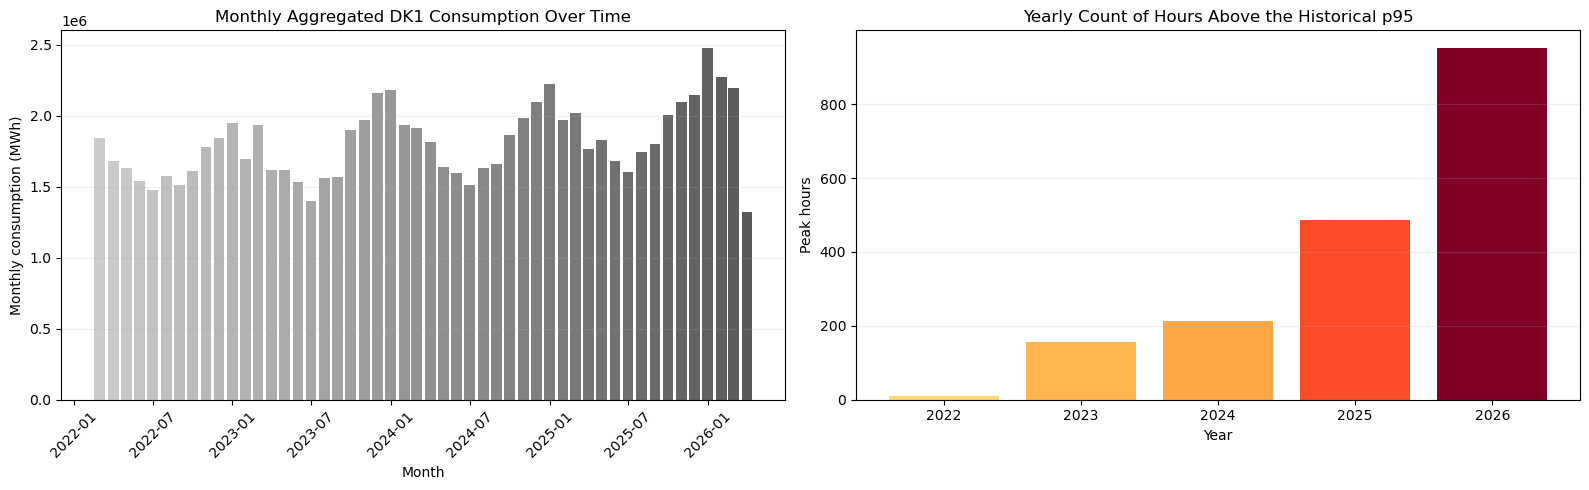

In [3]:
from src.analysis.energy_congestion_analysis import plot_consumption_trend_and_peak_hours

trend_and_peaks_figure, _ = plot_consumption_trend_and_peak_hours(grid_state)


The figures suggest that DK1 is not only characterised by recurring peak-load hours, but also by a broader upward development in electricity consumption over time. This strengthens the case for action: if demand continues to grow while peaks remain frequent, the grid becomes increasingly exposed to stress during already demanding hours. The resilience contribution of the project must therefore be understood as an attempt to improve the timing of consumption, shifting flexible demand away from periods where the system is already under pressure.

To do that in practice, households need more than a description of the current grid state. They need forward-looking signals that indicate when it is likely to be costly or beneficial to consume electricity. This is where forecasting enters the project: after defining the stress problem, the next step is to predict future electricity prices so they can be used as a decision signal for shifting demand.


## Forecast Analysis: Predicting hourly electricity prices 120 hours ahead


The forecast is the central analytical element of the project. Energy shifting is a timing decision: a household can only postpone EV charging, laundry, dishwashing, or heating if it has a credible signal that another hour in the near future will be cheaper or less stressful for the system. In DK1, prices are especially useful because they summarize market scarcity, demand, wind and solar production, interconnector conditions, and other system pressures in one observable hourly signal.

The purpose of the forecast is therefore broader than minimizing prediction error. It creates the forward-looking price profile that the dashboard later turns into recommendations. A good forecast should identify expensive periods, cheap windows, and the uncertainty around those signals, because the recommendation layer should be more confident when the predicted price difference is large and more cautious when the model has historically been noisy at that horizon.


### Data Acquisition: Prices, consumption, weather actuals, and weather forecasts
To forecast DK1 electricity prices, we first need data that describes the price itself and the conditions that influence it. We collect day-ahead prices, observed weather, previous-run weather forecasts, and consumption data. The raw files are saved in `data/`. The consumption data is later used to measure grid stress and simulate load shifting..
Data is collected from two public APIs — Energi Data Service for electricity prices and consumption, and Open-Meteo for historical weather actuals and NWP forecasts.

The main data sources are:

- `data/day_ahead_prices_dk1_raw.csv`: hourly day-ahead prices for DK1 from Energi Data Service.
- `data/consumption_dk1_raw.csv`: DK1 electricity consumption used later to measure grid stress and simulate load shifting.
- `data/weather_actuals_raw.csv`: historical weather observations for the DK1 weather location.
- `data/weather_forecasts_raw.csv`: previous-run weather forecasts from Open-Meteo, used to estimate forecast errors.

All raw datasets can be collected with one call:

In [ ]:
from src.data.data_collection import fetch_all

results = fetch_all(start="2021-01-01", end="2026-04-28", price_area="DK1")

As a quick check, we plot prices and actual weather for the same period. This helps confirm that the scraped time series line up and that the weather variables are relevant for price forecasting.

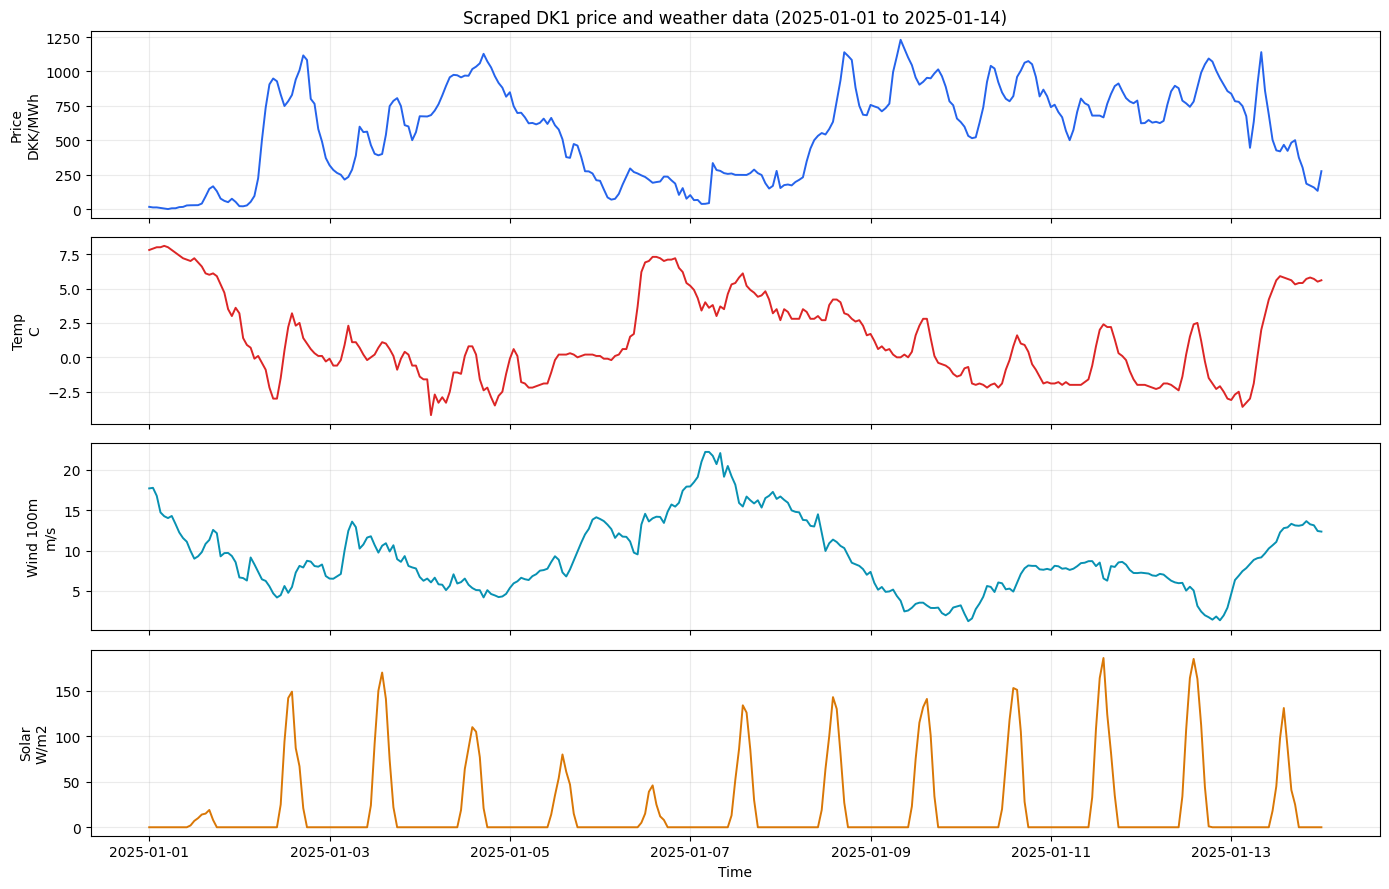

In [1]:
from src.analysis.forecast_analysis import plot_raw_price_and_weather

fig = plot_raw_price_and_weather(start="2025-01-01", end="2025-01-14")

The plot suggests the weather variables are useful predictors of DK1 electricity prices. Price movements appear to line up with changes in wind, temperature, and solar conditions: when wind drops or solar output is low, prices often rise, while stronger wind periods are associated with lower prices. Temperature also seems relevant, as colder periods may increase demand and contribute to higher prices. Overall, the visible movement between price and weather supports the idea that these variables contain predictive information for electricity prices.

### Data Processing: Building a leakage-safe forecast matrix
Before the data can be used for prediction, it must be transformed into the same format the model will see in practice. The key issue is weather data: at forecast time, future realised weather is not known. The model can only rely on weather forecasts.

Real previous-run weather forecasts are only available from 2025 onwards. This period is therefore used to estimate typical forecast errors. These errors are then applied to historical realised weather data to generate forecast-like weather inputs for the full historical period.

This step is important because using historical actual weather directly as a future predictor would create data leakage. The model would then learn from information that would not have been available at the time of making a real forecast. By replacing future actual weather with forecast-like inputs, the dataset better reflects the real forecasting situation.The estimated error distributions are saved in
- `data/weather_error_distributions.csv`:

The plot below shows how forecast error changes as the horizon increases.


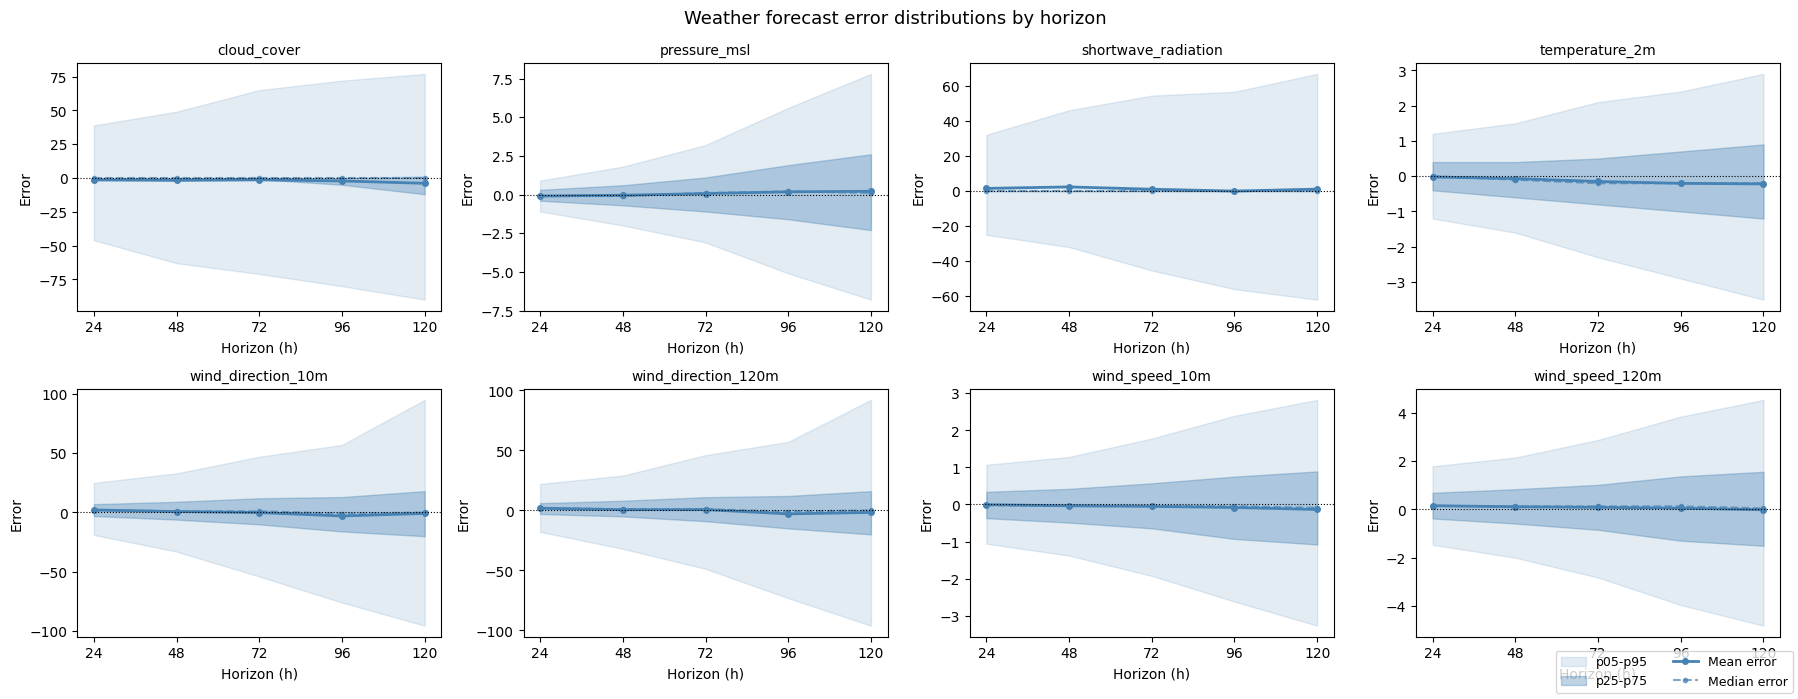

In [9]:
from src.data.data_processing import plot_weather_error_distributions

plot_weather_error_distributions()

The processing script `data/data_processing.py` creates 120 rows for each issue time, corresponding to forecast horizons from 1 to 120 hours ahead. Each row contains the issue time, target time, horizon, forecast-like weather variables, calendar variables, and price lags known at the issue time. To reflect increasing forecast uncertainty at longer horizons, the weather inputs are drawn from horizon-specific error distributions. The target variable is the realised day-ahead price at the target time.

The result is a leakage-safe forecast matrix that mirrors the information structure of the production dashboard: only information known at the issue time is used to forecast prices at later target times.

In the plots below, we can see how the forecast error is applied across different forecast horizons.

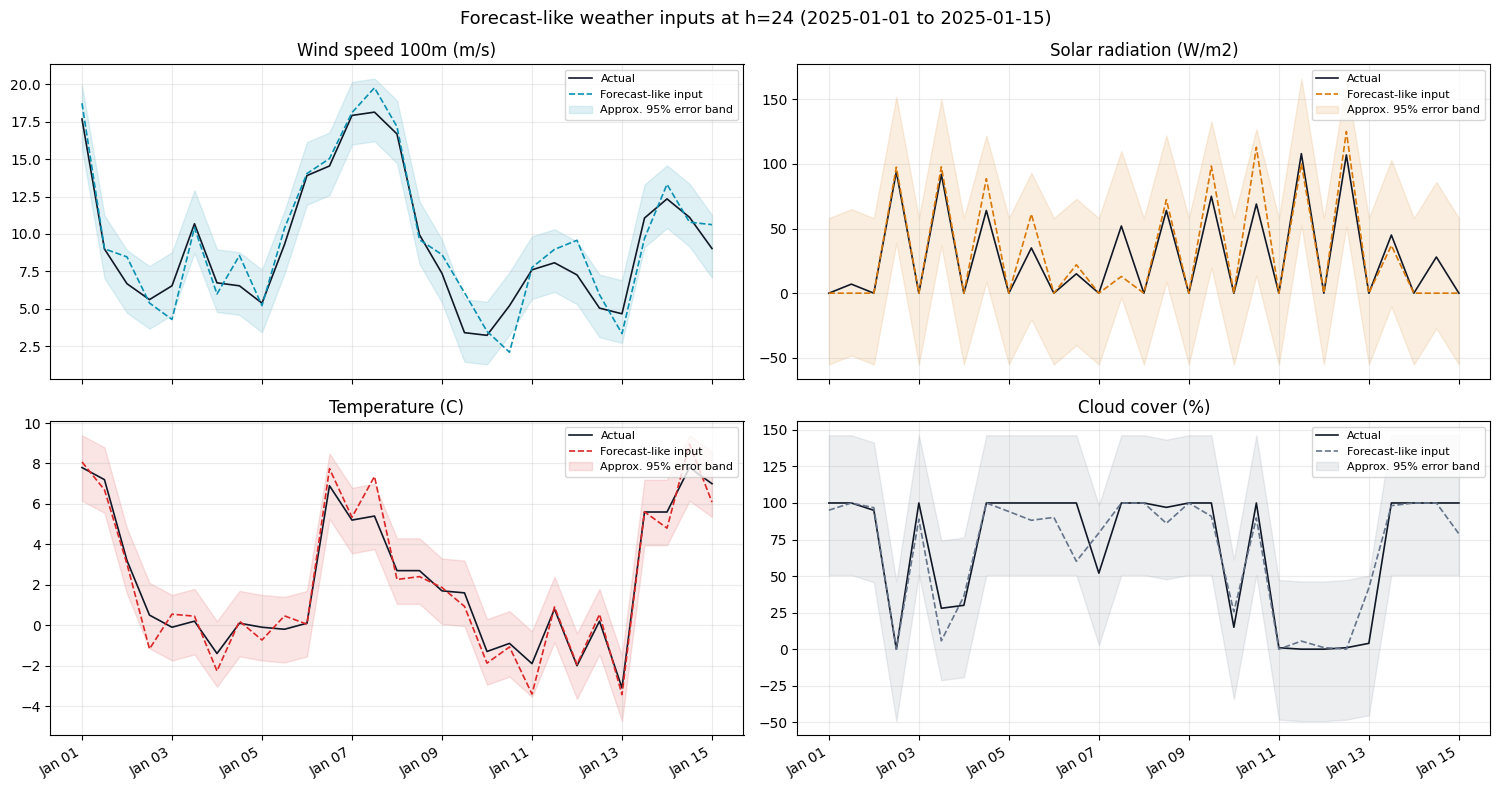

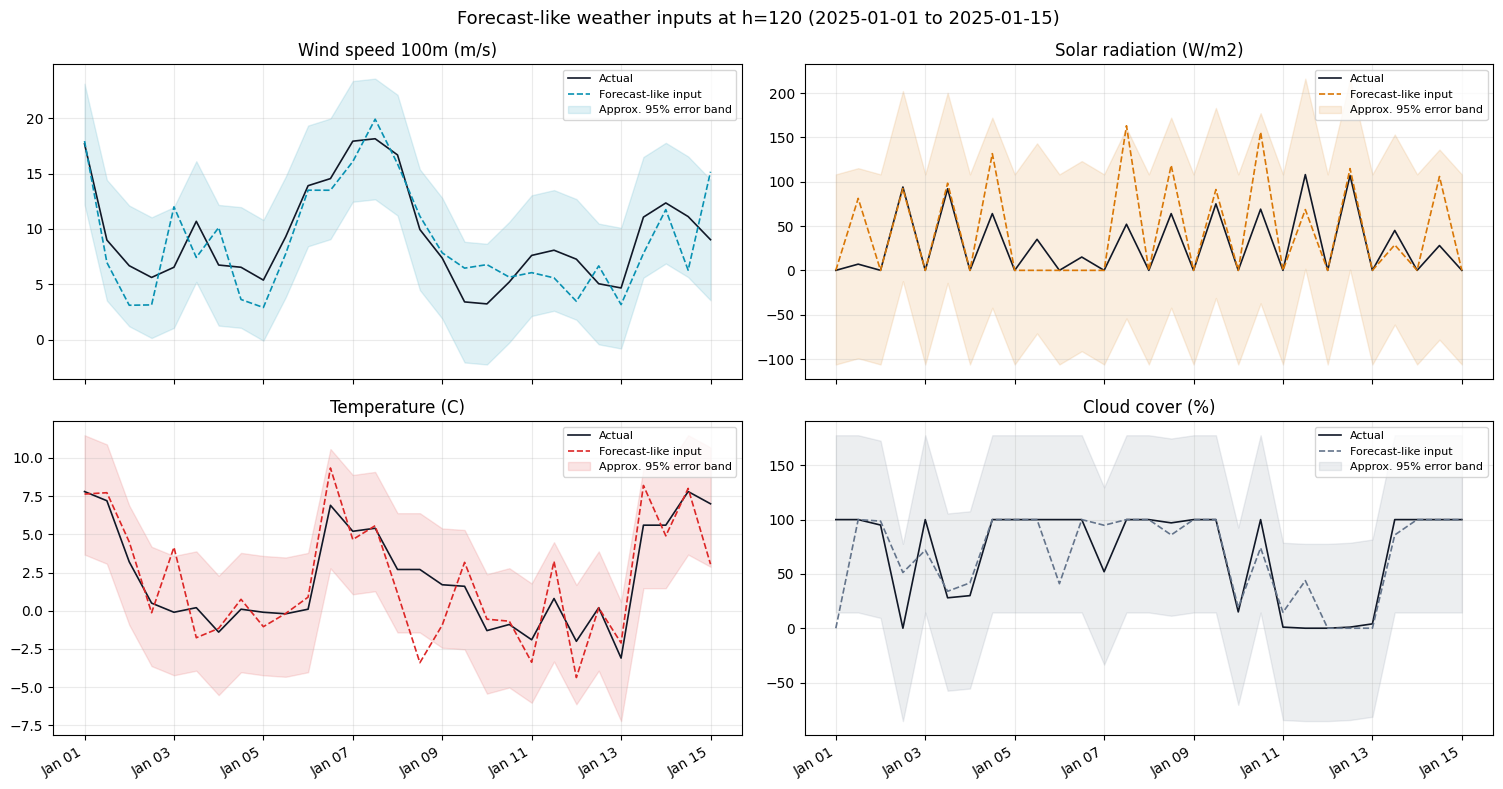

In [12]:
from src.analysis.forecast_analysis import plot_weather_forecast_grid

fig_24 = plot_weather_forecast_grid(horizon_hours=24)
fig_120 = plot_weather_forecast_grid(horizon_hours=120)



The weather plots show why the processing step is necessary. At a 24-hour horizon, the generated forecast-like weather variables generally follow the realised weather closely. At a 120-hour horizon, the deviations and uncertainty bands are wider. This is expected: longer weather forecasts are harder, and that uncertainty can propagate into electricity-price forecasts.

The implication for the recommender system is practical. A five-day forecast can still be valuable, but recommendations based on later horizons should be interpreted with more caution than recommendations based on the next few hours. This is one reason the forecast section evaluates both point accuracy and residual uncertainty by horizon.


Next examine which variables appear most informative for predicting future DK1 prices. For this purpose, we calculate the Pearson correlation between each feature and the target variable at the 120-hour horizon. This gives an initial indication of the strength and direction of the linear relationship between the input variables and the future price before fitting the forecasting models.

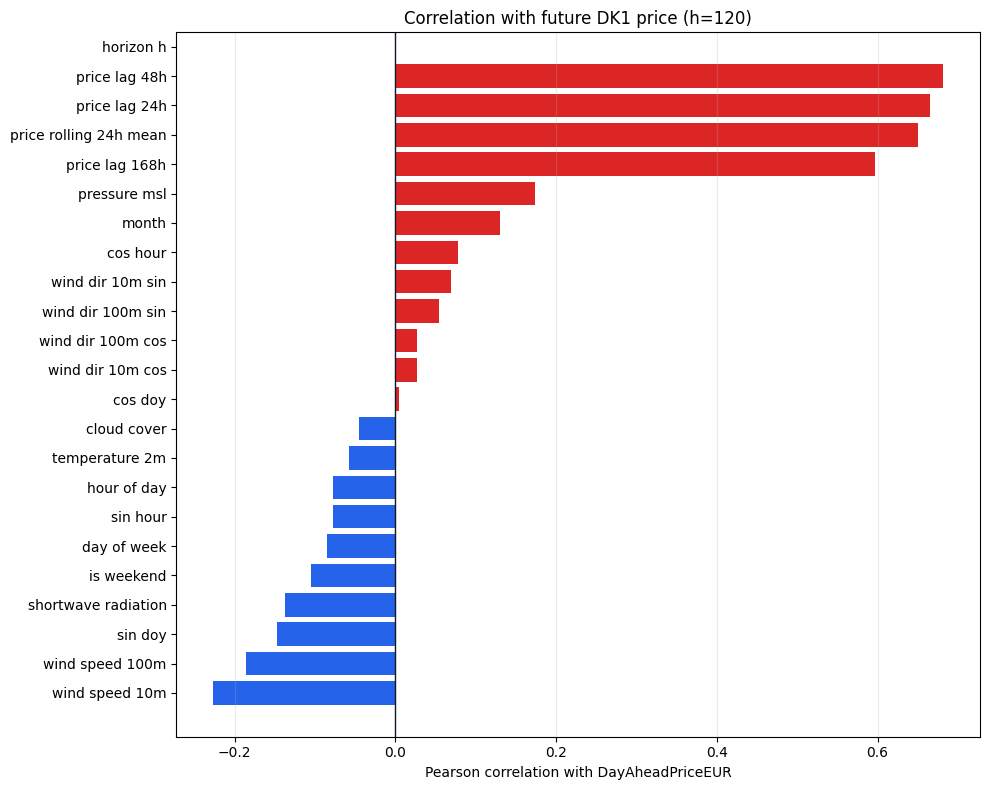

In [7]:
from src.analysis.forecast_analysis import plot_weather_price_correlation

fig = plot_weather_price_correlation(correlation_horizon=120)


The correlation plot is not a causal analysis but a sanity check — it confirms that the weather forecast variables and lagged price features carry statistical information about the future price target before any model is trained. Some relationships are likely nonlinear or context-dependent. Higher wind production, for example, tends to push prices down by increasing renewable supply, but the actual effect depends on demand, interconnector flows, and overall market conditions at the time. The variables shown here are exactly the features passed to the XGBoost model, and the full feature matrix is saved as`data/model_dataset.parquet`:

### XGBoost Forecasting Model

The forecasting model is implemented in `src/models/XG_Boost_full_Res.py`. The script trains five separate XGBoost regression models, one for each forecast day:

- Day 1: horizons 1-24 hours ahead.
- Day 2: horizons 25-48 hours ahead.
- Day 3: horizons 49-72 hours ahead.
- Day 4: horizons 73-96 hours ahead.
- Day 5: horizons 97-120 hours ahead.

This design is useful because short-horizon and long-horizon forecasts have different error structures. The next few hours are usually more anchored by recent prices and near-term weather forecasts, while later horizons are more uncertain and depend more on broader calendar and weather-pattern information. Splitting the model by forecast day lets each XGBoost regressor specialize in one part of the 120-hour horizon.

XGBoost is a good choice for this project because electricity prices are tabular, nonlinear, and interaction-heavy. Gradient-boosted trees can capture threshold effects, such as very low wind or peak-hour demand, without requiring all interactions to be manually specified. The method also works well with mixed calendar, lag, and weather features, requires little feature scaling, and can later be inspected using feature importance and SHAP. Finally, the model is fast enough to retrain and evaluate with walk-forward validation, which is important for a time-series forecasting problem. A Temporal Fusion Transformer was also tested, but it performed poorly compared with XGBoost. This is likely because the available dataset is relatively limited and the forecasting problem is mainly based on structured tabular features.

Validation is performed with an expanding walk-forward split. The first 12 months are used for training, the next 3 months are used for testing, and the training window then expands forward. This preserves the time order of the data and produces out-of-sample residuals that can be used both for accuracy metrics and uncertainty estimation.
The model performance is evaluated using MAE, since it measures the average forecast error in the same unit as the electricity price. It is easy to interpret and less affected by extreme price spikes than RMSE, making it suitable for assessing typical forecast accuracy.

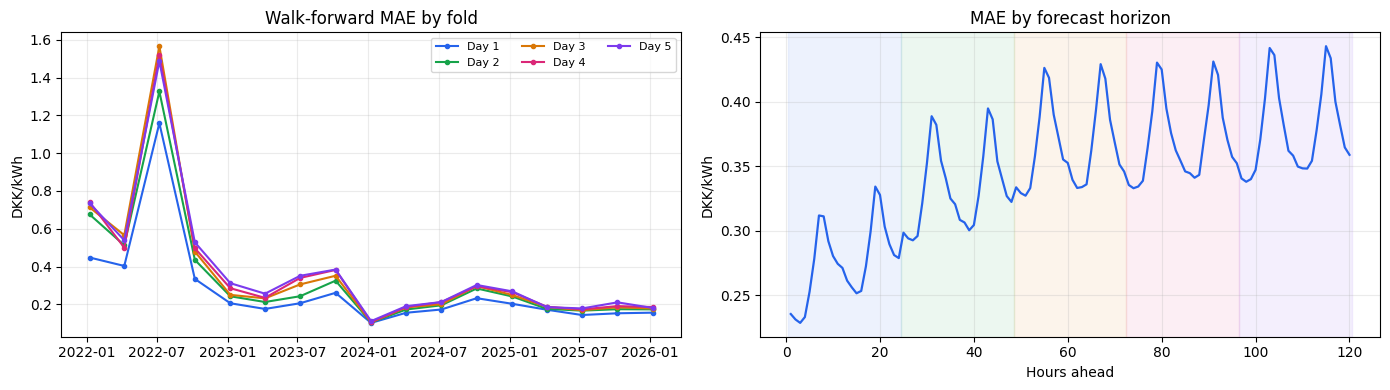

In [17]:
import matplotlib.pyplot as plt

from src.analysis.forecast_analysis import (
    COLORS,
    DAY_GROUPS,
    _horizon_metrics,
    _unit_scale,
    load_metrics,
    load_predictions,
)

unit = "dkk_kwh"
scale, label = _unit_scale(unit)
predictions = load_predictions()
metrics = load_metrics()
horizon_metrics = _horizon_metrics(predictions, unit)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for day in DAY_GROUPS:
    col = f"day{day}_mae"
    if col in metrics.columns:
        ax.plot(
            metrics["fold_end"],
            metrics[col] * scale,
            marker="o",
            linewidth=1.5,
            markersize=3,
            color=COLORS[day],
            label=f"Day {day}",
        )
ax.set_title("Walk-forward MAE by fold")
ax.set_ylabel(label)
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=8)

ax = axes[1]
ax.plot(horizon_metrics["horizon_h"], horizon_metrics["mae"], color="#2563eb", linewidth=1.6)
for day, (h_lo, h_hi) in DAY_GROUPS.items():
    ax.axvspan(h_lo - 0.5, h_hi + 0.5, color=COLORS[day], alpha=0.08)
ax.set_title("MAE by forecast horizon")
ax.set_xlabel("Hours ahead")
ax.set_ylabel(label)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()


The results should be read in two ways. First, the walk-forward fold plot shows whether performance is stable over time. Large errors around crisis or high-volatility periods are expected in electricity markets, because prices can spike when scarcity, fuel prices, outages, or interconnector conditions change abruptly. Second, the horizon plot shows how error develops across the 120-hour forecast window. This is directly relevant for recommendations: a predicted saving tomorrow is usually a stronger signal than a similarly sized predicted saving five days ahead if the five-day residual spread is much larger.

The forecast does not need to be perfect to be useful. For household flexibility, the key question is whether the model can rank future hours well enough to identify cheaper and more expensive windows. However, the size of the forecast error determines how forcefully the dashboard should communicate a recommendation. Small expected savings inside a wide error band should be framed cautiously, while large savings that exceed historical uncertainty can support a stronger recommendation.


### Price Prediction Uncertainty: Residual-based forecast bands

The lecture material on prediction uncertainty emphasizes that a prediction should not be treated only as a single expected value. A future price is uncertain, so a decision-support system should also communicate the spread around the point forecast. In this project we estimate uncertainty from the walk-forward residuals, because those residuals measure how wrong the model was on data that was not used for fitting.

For each out-of-sample prediction we compute the signed residual

$$
e_h = \hat{y}_h - y_h,
$$

where $\hat{y}_h$ is the predicted price for horizon $h$ and $y_h$ is the realised price. We then group residuals by `horizon_h` and calculate a horizon-specific standard deviation, $\sigma_h$. The simple forecast band used here is

$$
\hat{y}_h \pm \sigma_h.
$$

The diagnostics below use residuals from 1 January 2023 onward. This keeps the uncertainty estimate focused on the post-energy-crisis market regime, rather than letting the extreme 2022 volatility dominate the current dashboard bands. The band should be interpreted as an empirical prediction-uncertainty measure, not as a guarantee that prices will fall inside the interval.


In [ ]:
from src.analysis.forecast_analysis import (
    make_uncertainty_summary_table,
    plot_residual_diagnostics,
    plot_single_forecast_with_uncertainty,
)

plot_single_forecast_with_uncertainty(unit="dkk_kwh")
plot_residual_diagnostics(unit="dkk_kwh")

make_uncertainty_summary_table(unit="dkk_kwh").style.format(
    {
        "Mean residual sigma (DKK/kWh)": "{:.3f}",
        "Max residual sigma (DKK/kWh)": "{:.3f}",
        "Mean P90 abs error (DKK/kWh)": "{:.3f}",
        "Mean bias (DKK/kWh)": "{:+.3f}",
        "residual_sample_size": "{:,}",
    }
)


Uncertainty is essential for the recommendation layer. The dashboard should not only ask whether a future hour is predicted to be cheaper, but whether the predicted difference is large relative to the model's historical error at that horizon. If the cheapest future window is only slightly below the current price and the residual band is wide, the recommendation should be softer: waiting may help, but the signal is uncertain. If the predicted price drop is much larger than the residual spread, the forecast can reinforce a stronger recommendation to delay flexible consumption.

The same logic applies to warnings about expensive periods. A high-price warning is more credible when the predicted expensive block remains expensive even after accounting for historical forecast error. In this way, uncertainty does not weaken the project. It makes the forecast more decision-ready by showing when the model signal is strong enough to act on and when household advice should be framed as cautious rather than definitive.


## Explainable AI: SHAP and LIME for a decision-support forecast

The forecasting model produces a 120-hour price profile for DK1. The recommendation layer then translates that profile into timing advice: whether a household should consume now to avoid an expensive period or wait for a cheaper window. Explainable AI sits between these two steps. Its purpose is to show which input variables are driving the predicted prices that later become household recommendations.

In this project, XAI has three roles. First, it checks whether the XGBoost models rely on plausible electricity-market drivers such as recent price levels, forecasted wind, solar radiation, temperature, cloud cover, and calendar effects. Second, it supports the dashboard by turning the model from a black box into an inspectable forecast engine. Third, it strengthens the later impact analysis: if simulated load shifting depends on model-based price signals, we should understand what produced those signals before interpreting the estimated system benefit.


In [10]:
import joblib

from src.analysis.explainable_ai import (
    OUTPUT_DIR,
    make_dashboard_shap_summary,
    plot_feature_importance,
    plot_lime_explanations,
    plot_shap_explanations,
)

final_models = joblib.load(OUTPUT_DIR / "final_day_models.joblib")


We start with XGBoost feature importance as a coarse global view. The model is split into five day-specific regressors, so the plot shows whether the short-horizon and long-horizon forecasts depend on similar drivers or whether the dominant predictors change across the 120-hour forecast window.


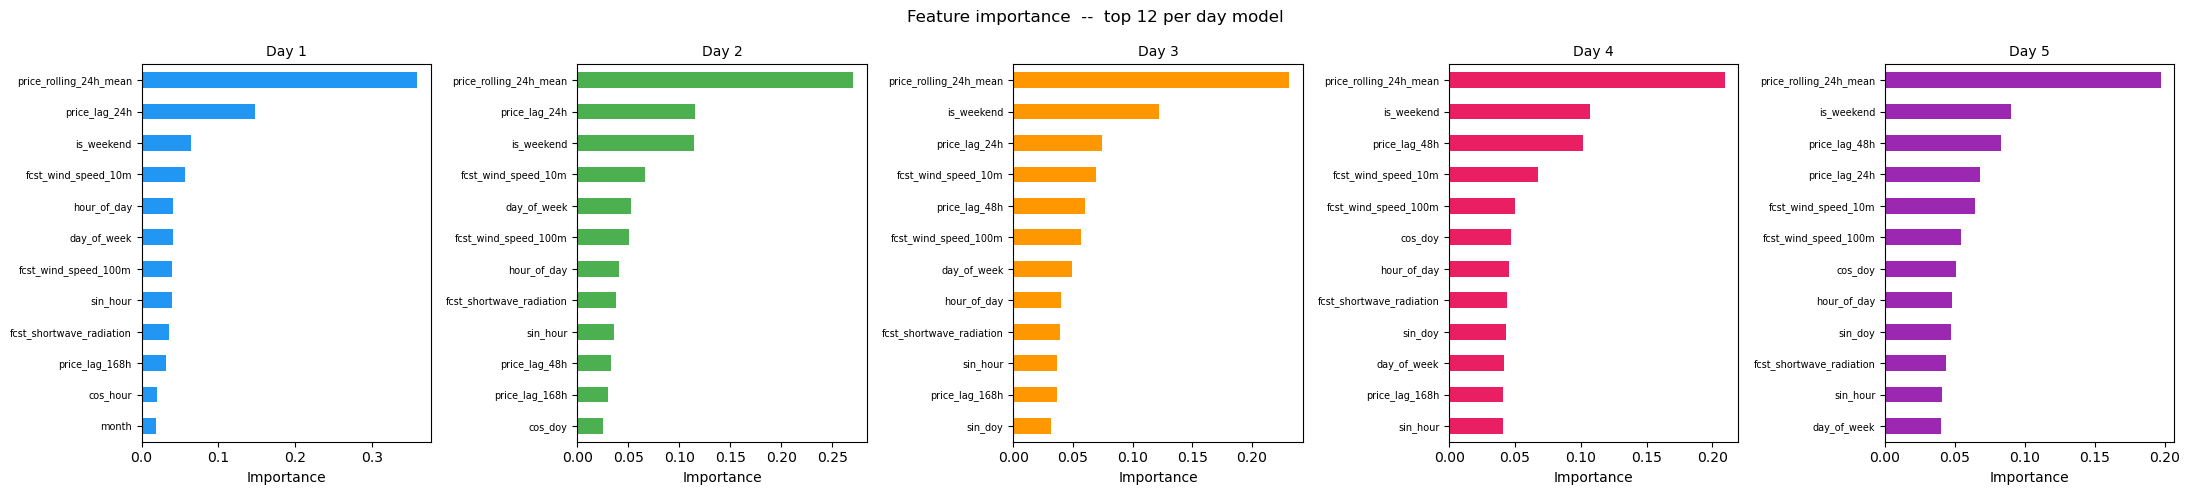

In [11]:
plot_feature_importance(final_models)


Feature importance is useful as an entry point, but it does not show whether a feature pushes the forecast up or down. It can also blur correlated drivers. We therefore use SHAP as the main global explanation method. SHAP decomposes each forecast into additive feature contributions, which is useful when the dashboard recommends a timing decision and we want to understand why a cheap or expensive window appears in the forecast.


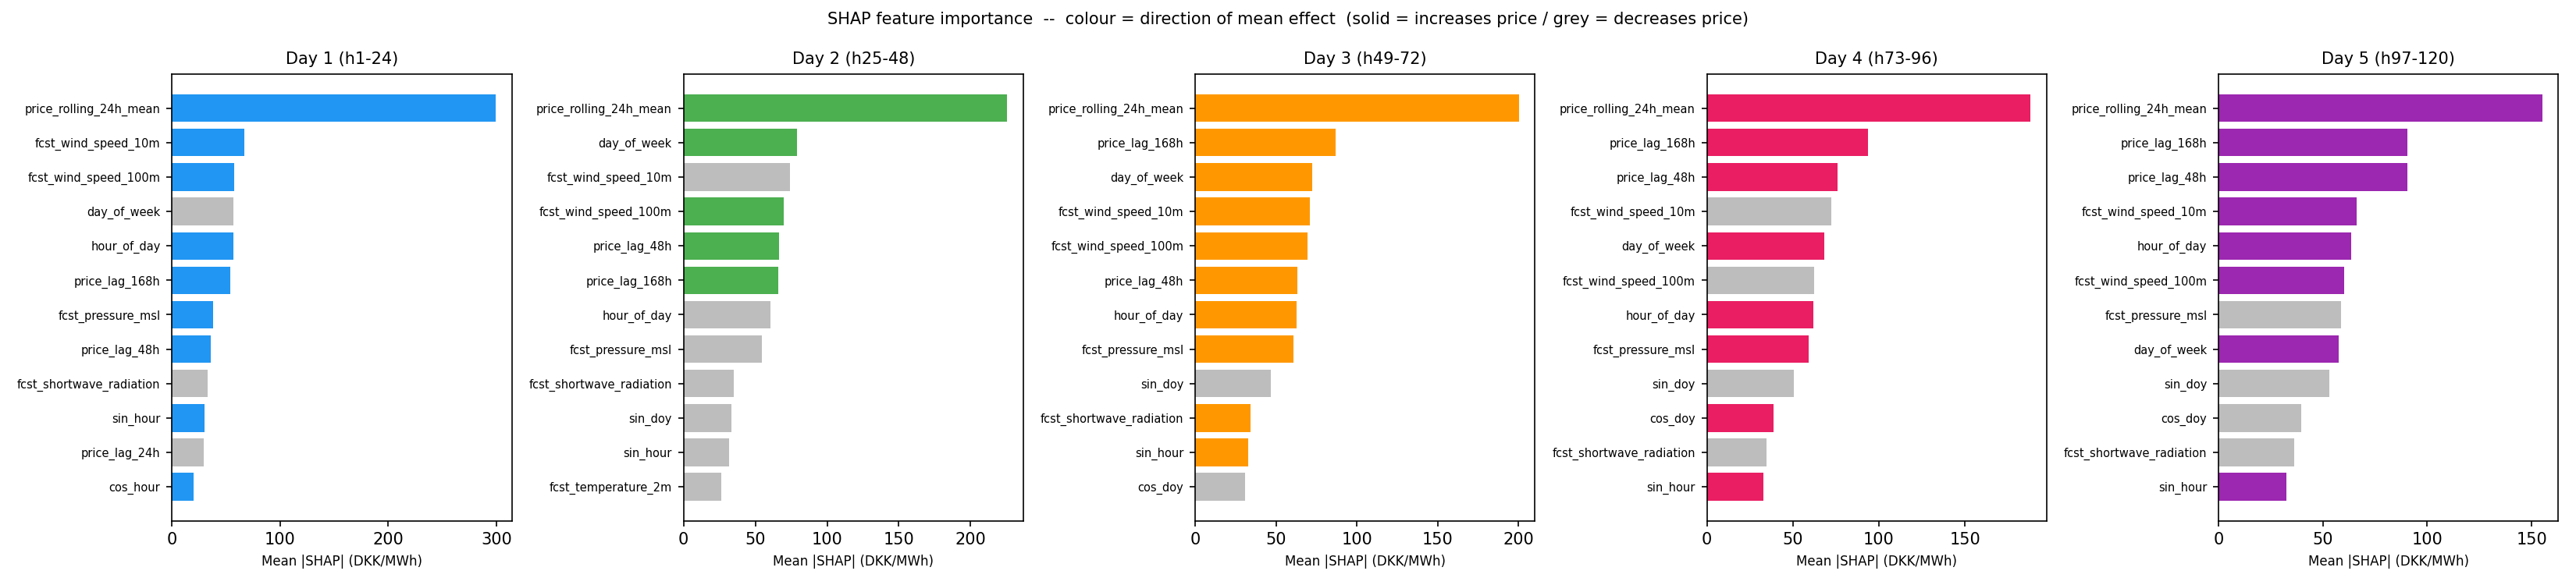

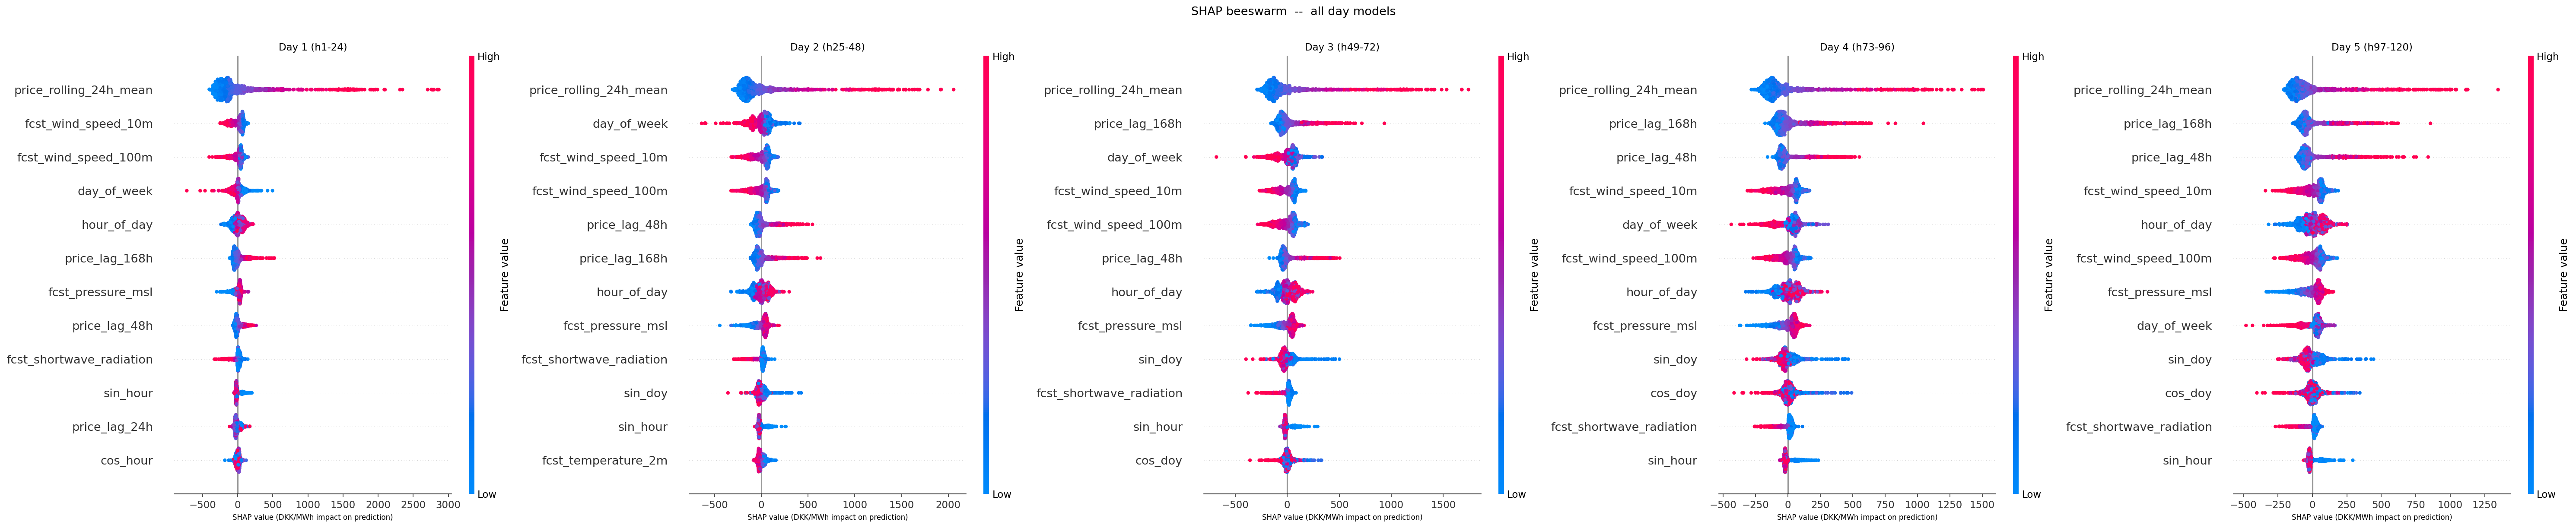

In [12]:
plot_shap_explanations(width=1200)


The SHAP bar plot ranks features by their average absolute contribution to the price forecast, while the beeswarm plot shows the distribution and direction of effects across many sampled forecasts. This distinction matters for recommendations: a feature may be important because high values consistently lift predicted prices, because low values depress prices, or because the effect changes across market regimes.

For the project objective, households do not need to read SHAP plots before using the app. The value is that SHAP gives the project team and dashboard a transparent link between the forecast signal and the market story behind it. A recommendation to wait should be traceable to sensible drivers such as renewable availability, recent price persistence, demand-sensitive weather, or time-of-day effects rather than an arbitrary model artifact.


In [13]:
dashboard_shap_summary = make_dashboard_shap_summary(top_n=8)
dashboard_shap_summary.style.format(
    {
        "mean_abs_shap_dkk_kwh": "{:.4f}",
        "mean_signed_shap_dkk_kwh": "{:+.4f}",
        "sample_mean_feature_value": "{:.2f}",
    }
)


,feature,mean_abs_shap_dkk_kwh,mean_signed_shap_dkk_kwh,sample_mean_feature_value
0,price_rolling_24h_mean,0.3028,+0.0493,116.72
1,fcst_wind_speed_10m,0.0677,+0.0029,4.44
2,day_of_week,0.0601,-0.0055,3.22
3,fcst_wind_speed_100m,0.0576,+0.0010,7.51
4,price_lag_168h,0.0570,+0.0076,103.19
5,hour_of_day,0.0543,+0.0034,11.69
6,fcst_pressure_msl,0.0372,+0.0042,1013.88
7,price_lag_48h,0.0368,+0.0116,102.40


The table above uses the same Day 1 SHAP export that is loaded by `dashboard.py` from `outputs/model/shap_day1_values.parquet` and `outputs/model/shap_day1_features.parquet`. This allows the Streamlit app to show a lightweight model-insight panel without recomputing SHAP live.

In the dashboard context, this turns XAI into a communication layer. The recommendation text can stay simple and practical, while the app still exposes enough model transparency to answer the natural follow-up question: "why does the model think this period is cheap or expensive?" A future version could use the same SHAP values to generate short explanation snippets next to each recommendation, for example identifying whether a high-price warning is mainly linked to low wind, high recent prices, or peak-hour demand patterns.


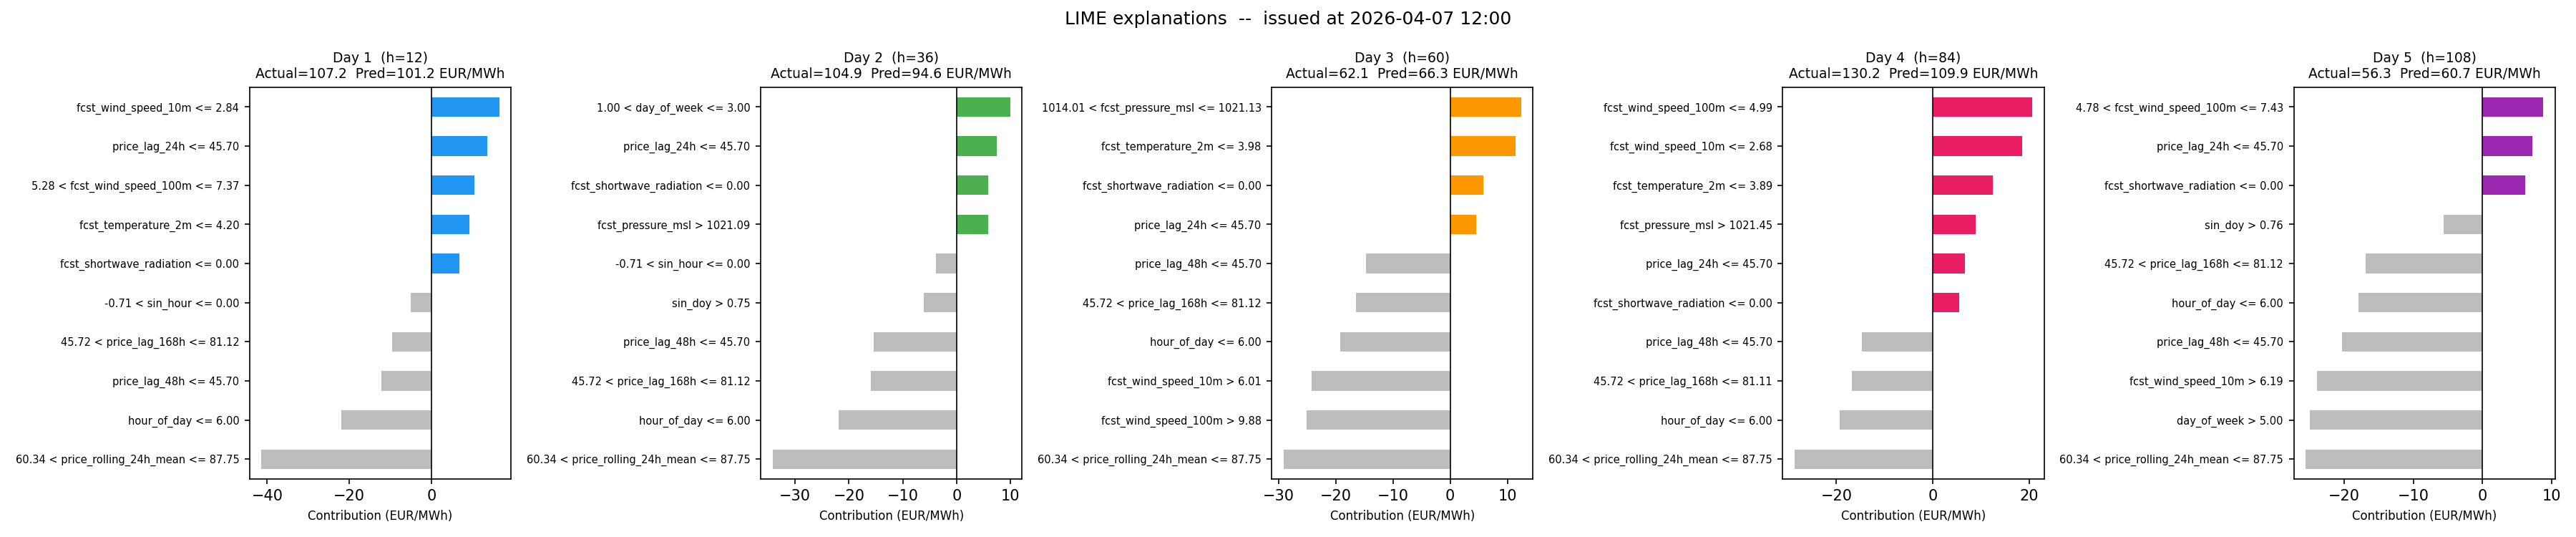

In [14]:
plot_lime_explanations(width=1200)


LIME complements SHAP by focusing on one concrete forecast issue time. It fits a simple local surrogate around the selected forecast instance and shows which features pushed that specific prediction upward or downward. In other words, SHAP answers "what generally drives this model?", while LIME helps answer "why did the model make this recommendation now?"

This local view is important for a consumer recommendation system because the same global model can produce different advice on different days. On one day, the recommended cheap window may be explained by strong wind and low recent prices. On another, a warning to consume earlier may be explained by lower renewable availability, higher lagged prices, and a peak-hour calendar effect.

This also matters for the final impact analysis. The shifting simulation estimates what happens when households react to forecast-based recommendations. XAI does not prove that the behavioral impact will occur, but it makes the mechanism more credible: the simulated shifts are based on price signals that can be inspected and related back to recognizable market drivers. If the impact model shows large benefits while SHAP or LIME reveals that the forecast signal is driven by an implausible artifact, that would be a warning sign before interpreting the resilience contribution.

After retraining the XGBoost models, the XAI artifacts and dashboard SHAP files should be refreshed with `python src/analysis/explainable_ai.py`.


## User dashboard: Household Recommendations

Forecasts alone are not enough for most households. A table of predicted prices is technically useful, but it does not automatically answer the practical question: **Should I run this flexible load now or later?**

The Streamlit dashboard in `dashboard.py` translates the 120-hour forecast state into daily outlooks, cheap windows, historical context, and household-oriented advice. The XAI outputs from the previous section support this step by making the forecast more inspectable: feature importance and SHAP are shown as model insight panels, while LIME-style local explanations can be used to audit individual recommendations when the model suggests waiting, consuming earlier, or shifting demand into a cheaper period.


In [ ]:
from src.analysis.forecast_analysis import preview_recommendation_workflow  # placeholder

preview_recommendation_workflow()


This step connects analytics to behavior. The recommendation does not require the household to understand residual uncertainty, XGBoost, or electricity-market dynamics. Instead, it communicates whether waiting is expected to be valuable and whether an upcoming period looks unusually expensive.

For a real deployment, the forecast table would be produced by the trained price model. In this notebook draft, the same recommendation functions are demonstrated with a forecast-like table so the logic is visible and easy to inspect.

## Modelling of impact: Rolling 120 hour energy shift heuristic

This section connects the forecasting and recommendation components directly to the resilience question. The objective is not only to assess whether households can respond to price signals, but to evaluate whether such responses meaningfully change the timing of demand in a way that reduces pressure during stressed periods in the DK1 system.

To answer this, the project develops an impact modelling and simulation framework that translates forecast-guided household behaviour into a system-level effect. The resulting simulations therefore serve as the core evidence for assessing the resilience contribution of the proposed approach.

### Energy shift heuristic
As illustrated in the figure, the impact is driven by many decentralised decisions made by households under uncertainty, constraints, and limited flexibility. Modelling such behaviour exactly would require detailed knowledge of user preferences, appliance availability, and real-time decision-making, which is not observable in the available data.

A heuristic approach is therefore appropriate, as it provides a **structured and transparent approximation of behaviour** under realistic constraints. Rather than assuming perfect optimisation, the heuristic captures key behavioural mechanisms:
- Households respond to **price signals**
- They are limited by **waiting times and flexibility constraints**
- They cannot shift all demand and must respect **capacity limits**

The heuristic thus represents a **bounded rational decision process**, where households shift consumption when it is beneficial, but only within realistic limits. This makes it well-suited for estimating system-level impact while maintaining interpretability and control over assumptions.

![Illustration of the rolling 120-hour energy shift heuristic](ABA_heuristic_illustration.png)



The figure outlines a **Step-by-step simulation of behaviour** on how the heuristic is applied across the simulation horizon to model household behaviour dynamically.

1. **Select issue times**  
   The simulation starts by selecting decision points where forecasts and recommendations are generated.

2. **Build a 120-hour window**  
   For each issue time, the model considers the next 120 hours of forecasted prices and actual system load. This defines the decision horizon available to the household.

3. **Create baseline and segments**  
   The household share is separated from the total system load and divided into behavioural segments: inflexible demand, wet loads, thermal demand, and EV charging.  
   Each segment is assigned a demand share, a maximum shiftable share, and a maximum waiting time.

4. **Evaluate candidate hours**  
   For each hour and each flexible segment, the model compares the current hour with future candidate hours inside the allowed waiting window.  
   Candidate hours with lower forecasted prices receive better scores, while longer waiting times are penalised.

5. **Shift energy subject to constraints**  
   If a future hour has a better score than the current hour, part of the flexible load is shifted to that hour.  
   The shift is only accepted if it respects the segment capacity, maximum waiting time, and maximum shiftable share.

6. **Repeat hour by hour**  
   The process is repeated sequentially across the 120-hour window. Over time, many small shifting decisions accumulate into a modified household and system load profile.

7. **Measure resilience impact**  
   The shifted load profile is compared with the baseline load profile. The resilience effect is measured by how much cumulative load above the historical p95 peak threshold is reduced.

### 90-day simulation of shifted consumption

After the heuristic is defined, we simulate its effect hour for hour. For each selected issue time, the model decides what flexible energy to keep, what to move out of the current hour, and where to place it within the next 120 hours. The outputs are shifted household load, shifted system load, realized energy movement, and cost-based summary metrics.

To keep the impact section aligned with the forecasting evaluation, the simulation is run over the last 90 days. This is the same time span used as the final forecast test period. Because each forecast covers five days, we use non-overlapping 120-hour windows so that the 90-day impact estimate is not double-counting the same hours.

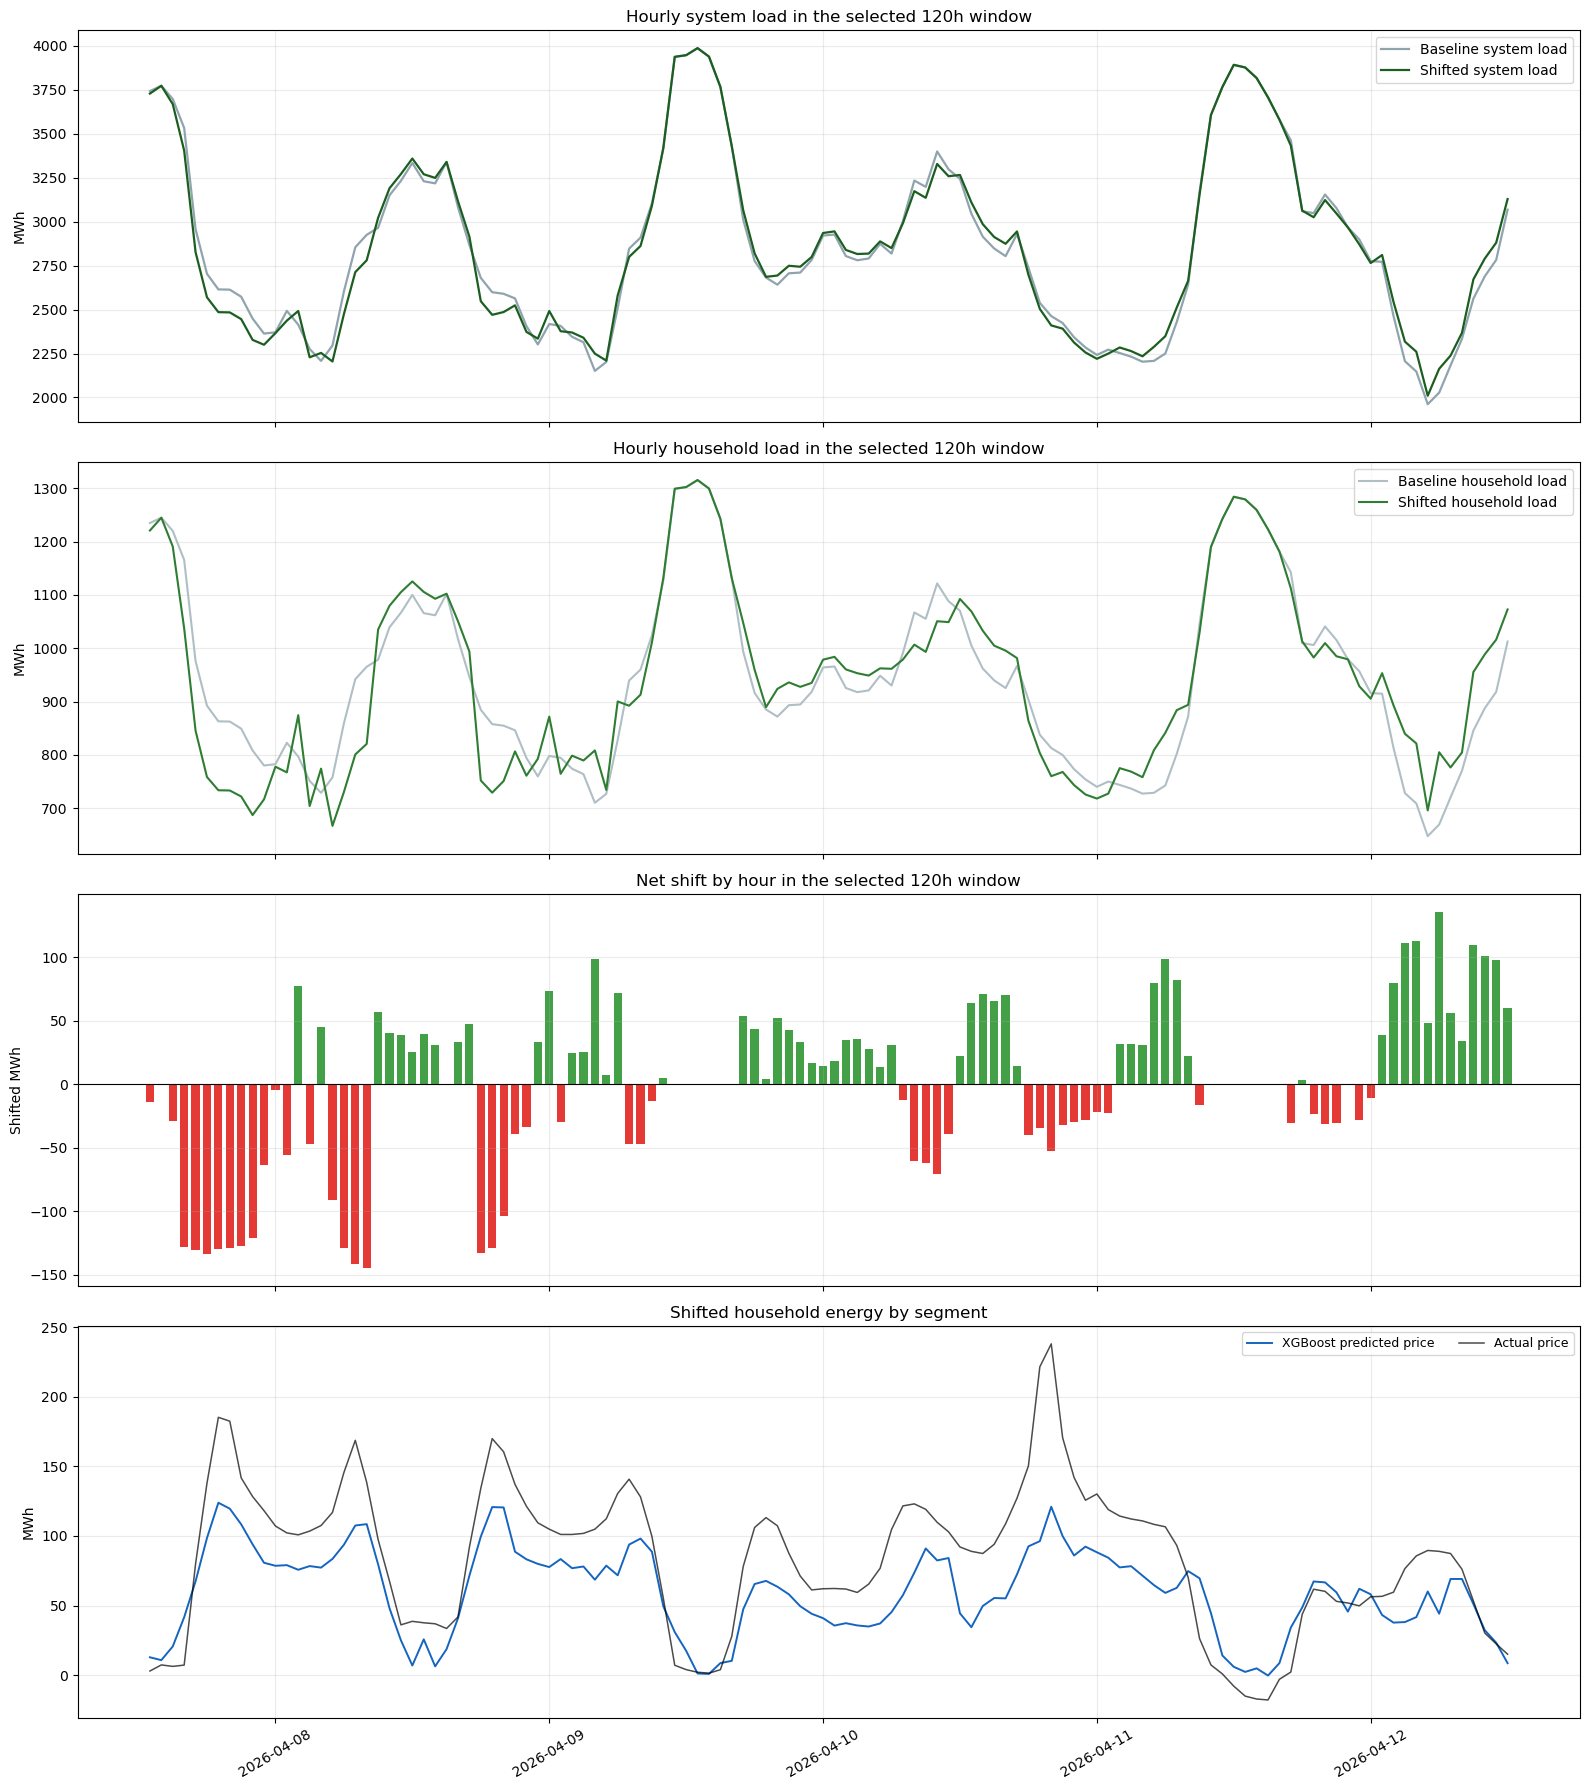

In [7]:
from src.analysis.impact_analysis import run_granular_shift_illustration

granular_result = run_granular_shift_illustration()
# display(granular_result["summary"].to_frame("value"))

The four plots collectively illustrate how forecast-driven household behavior translates into measurable, but constrained, resilience improvements.

At the system and household load level (top two plots), the shifted profiles closely follow the baseline shape, confirming that total energy is preserved. The impact is therefore not a structural change in demand, but a temporal redistribution. The most visible effect occurs around peak periods, where the shifted load is slightly reduced and redistributed to adjacent hours. This demonstrates that the method successfully targets high-stress periods, but only partially flattens them.

The net shift plot (third panel) makes the behavioral mechanism explicit. Negative values (red) coincide with high-load periods, indicating that consumption is actively moved away from peaks, while positive values (green) appear in lower-load periods, where energy is reallocated. This reflects the intended optimization: households delay or advance flexible consumption within the allowed waiting window. The clustering of shifts suggests that behavior is not continuous, but occurs in discrete, opportunistic adjustments when favorable alternatives exist.

The price context (bottom plot) explains why these shifts occur. Periods with high actual and predicted prices align with negative shifts, confirming that households respond to price signals as intended. Conversely, periods with low or moderate prices show little or no shifting—even when system load is relatively high. This reveals a key behavioral constraint: shifting is driven by economic incentives, not directly by grid need.

**The central insight on resilience impact:**
The method improves resilience by aligning flexible demand with price signals, which indirectly reduces pressure during some peak periods. However, the effect is selective rather than comprehensive. Peaks are reduced where price signals are strong, but persist where prices fail to reflect system stress. As a result, resilience gains are visible but moderate. The system benefits from smoother load profiles and reduced peak intensity, yet the remaining peaks highlight that price-based demand shifting alone cannot fully resolve grid pressure.


#### Behavior patterns across days and hours
While the previous figures illustrate how shifting reduces peak pressure within a specific time window, it is equally important to understand whether these effects follow systematic temporal patterns. The following heatmap aggregates the net shift across the full evaluation period by hour of day and day of week. This provides insight into when shifting occurs on average, and whether the heuristic consistently responds to recurring price signals rather than isolated events.


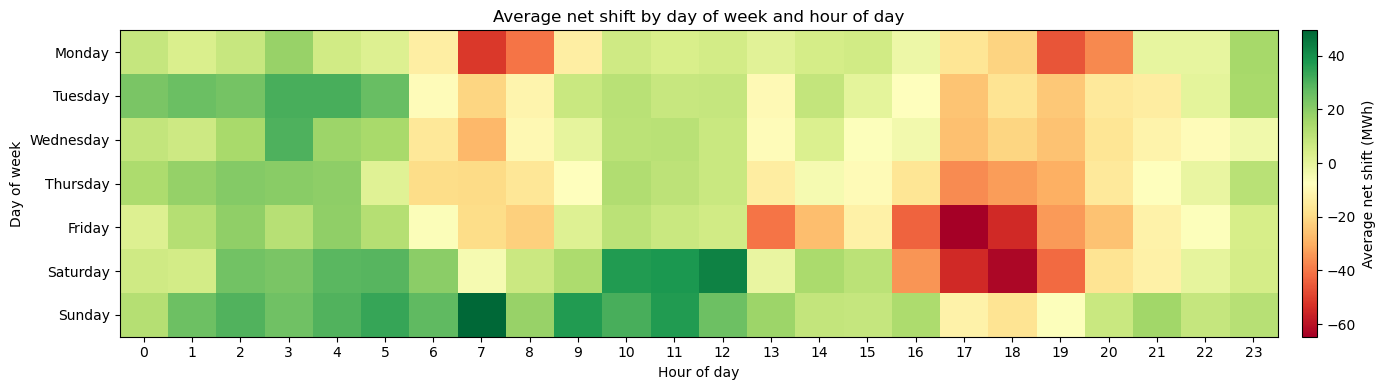

In [8]:
from src.analysis.impact_analysis import (
    plot_average_net_shift_heatmap,
    run_90_day_impact_simulation,
)

impact_90d = run_90_day_impact_simulation(simulation_days=90)
heatmap_df, _, _ = plot_average_net_shift_heatmap(impact_90d["profiles"])


The heatmap reveals a clear and structured pattern in shifting behavior, which supports both the validity of the heuristic and its contribution to resilience.

First, a consistent morning inflow of energy (green) is observed, particularly in the early hours (around 02:00–06:00) and again mid-morning. These periods typically correspond to lower electricity prices, indicating that the model systematically reallocates demand toward hours with favorable system conditions. In contrast, evening hours (approximately 17:00–20:00) show strong negative shifts (red), especially toward the end of the week. These hours coincide with well-known peak demand periods, where both consumption and prices tend to be high. The model therefore successfully identifies and avoids structurally stressed periods, rather than reacting randomly. This pattern is particularly pronounced on Fridays and Saturdays, where evening peaks are both larger and more consistently reduced. This suggests that the heuristic captures not only hourly dynamics but also weekly behavioral and price structures, which strengthens confidence in its general applicability.

**From a resilience perspective**, this is important because it shows that the model contributes to predictable and repeatable load smoothing, rather than ad hoc adjustments. By consistently shifting demand away from recurring peak periods, the method helps reduce systemic stress in the hours where the grid is most vulnerable. At the same time, the heatmap also highlights limitations. Not all peak periods are fully mitigated, and some hours show only modest or no shifting. This indicates that the heuristic is constrained by the availability of economically attractive alternatives and the imposed waiting-time limits.

#### Overall simulated impact:
The heatmap demonstrated that the shifting heuristic produces consistent and structured behavioral patterns across hours and days, systematically moving demand away from recurring peak periods. However, while these temporal patterns validate how the model behaves, they do not directly quantify how much this behavior contributes to resilience. To assess the overall system-level impact, the following figure aggregates the effect across the full 90-day horizon, measuring the reduction in load above the historical p95 threshold.


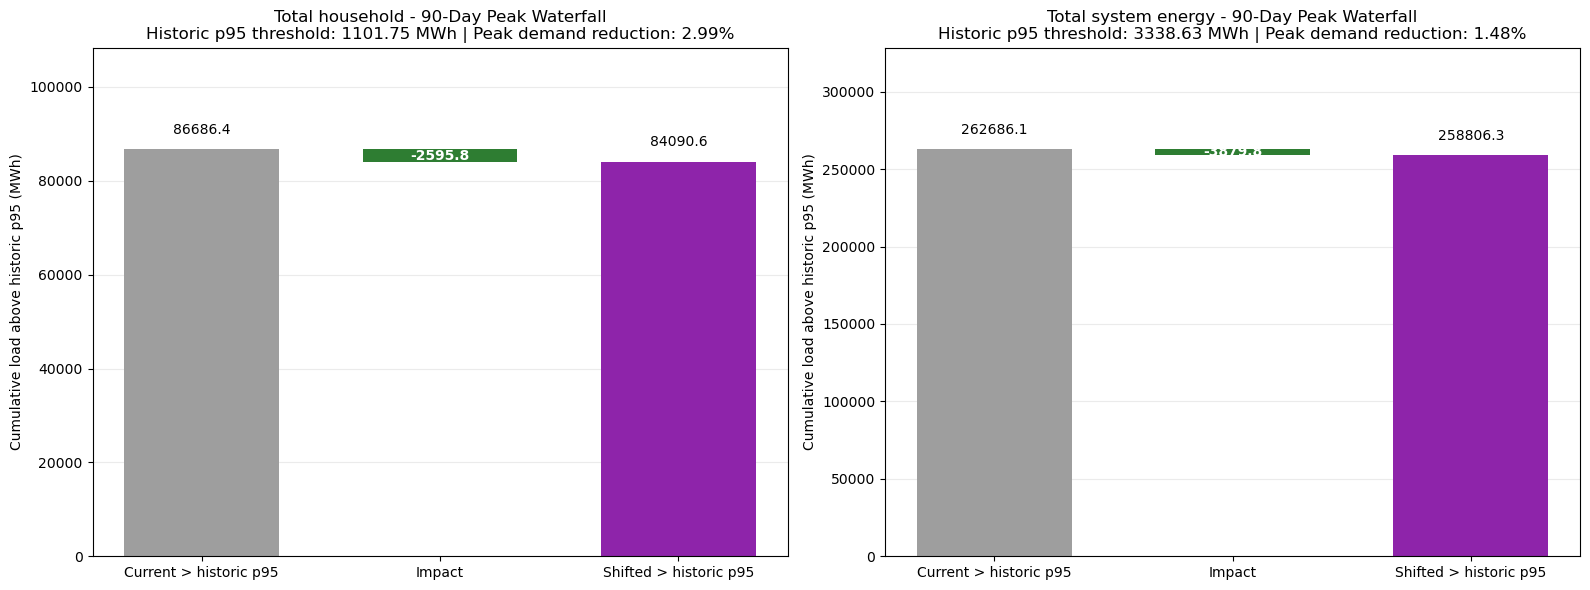

In [9]:
from src.analysis.impact_analysis import plot_peak_excess_waterfalls

peak_summary_df, _, _ = plot_peak_excess_waterfalls(
    impact_90d["profiles"],
    impact_90d["system_load"],
)


At the household level, the model reduces cumulative load above the p95 threshold by 3.01%, corresponding to a reduction of approximately 2,614 MWh. This confirms that forecast-guided shifting successfully targets the most extreme consumption periods and redistributes a meaningful share of flexible demand.

At the system level, the corresponding reduction is 1.48%, reflecting that households represent only a fraction of total demand. While smaller in relative terms, this result is important: it demonstrates that **local behavioral adjustments can scale to system-level effects, even when applied to a limited share of consumption.**

Importantly, the waterfall structure highlights that the reduction is achieved without lowering total energy consumption. The impact arises purely from reducing the magnitude and duration of peak exceedances, rather than eliminating demand. This reinforces the interpretation of the method as a load-shaping mechanism rather than a demand-reduction strategy.

**From a resilience perspective**, this reduction implies that the system spends less time in its most stressed operating regime. Even moderate reductions in peak pressure can improve system stability, reduce the need for costly balancing actions, and enable better integration of renewable energy.


### Assumptions behind the heuristic

The impact model rests on a small set of transparent assumptions. The most important are the estimated household share of total system demand, the segment split inside household demand, the maximum shiftable share in each segment, and the allowed waiting time before the energy service must still be delivered.

These are scenario choices rather than measured behavioral truths. They define what the heuristic is allowed to move. The tables below therefore should be read as the behavioral boundary of the simulation: if the shiftable shares or waiting windows change, the estimated impact changes as well.

In [1]:
from src.analysis.impact_analysis import display_heuristic_assumption_tables

display_heuristic_assumption_tables()

| Assumption | Value |
|---|---:|
| Household share of total system load | 33.0% |
| Flexible share of household load | 40.0% |
| Maximum theoretical shiftable share of household load | 15.0% |
| Maximum theoretical shiftable share of total system load | 5.0% |

| Segment | Share of household load | Max shiftable share within segment | Max shiftable share of household load | Max wait | Wait penalty |
|---|---:|---:|---:|---:|---:|
| Inflexible load | 60.0% | 0.0% | 0.0% | 0 h | 0.00 |
| Wet loads | 10.0% | 35.0% | 3.5% | 48 h | 0.90 |
| Thermal load | 20.0% | 15.0% | 3.0% | 24 h | 1.20 |
| EV charging | 10.0% | 85.0% | 8.5% | 120 h | 0.35 |

**Conclusion from the assumptions table.**

The assumptions make clear that the model is intentionally conservative. A large share of household demand remains inflexible, and even the flexible segments are only partly movable. EV charging receives the largest flexibility window, while wet loads and thermal demand are more constrained, which reflects the idea that not all energy services can wait equally long.

This matters for the interpretation of the whole impact section. If the model still produces measurable peak reduction under these limits, the result is more credible than if it had been built on near-perfect flexibility. At the same time, the assumptions also define the ceiling of the analysis: stronger flexibility adoption or different segment shares would likely increase the estimated impact.

## Discussion of resilience impact and limitation to the approach
The project shows that intelligent methods can contribute to grid resilience by turning price forecasts into actionable energy recommendation that causes household energy shifts. **The evidence suggests a measurable but moderate reduction in peak pressure of 3% on the household energy grid of a 90-day horizon.** The main insight is therefore not that household shifting alone solves grid congestion, but that price forecasting and explainable energy recommendations can become one layer in a broader resilience strategy. Stronger results would require real behavioral validation, local grid constraints, richer forecast inputs, and optimization that explicitly balances household comfort, cost savings, and system-level resilience.

The disruption considered in this project is the increasing pressure on the electricity system caused by rising demand and a larger share of variable renewable energy. Since direct grid congestion data was not available, historical system consumption was used as a proxy for grid stress, with hours above the historical p95 threshold interpreted as peak-pressure periods. The proposed solution combines an XGBoost price forecasting model, uncertainty bands, explainable AI methods, and a household shifting heuristic. The forecasting model predicts hourly prices up to 120 hours ahead, while SHAP and LIME are used to inspect whether the forecast signal is driven by plausible market factors. The shifting heuristic then simulates how flexible household demand could be moved away from expensive and stressed hours.
The main evidence is the 90-day impact simulation. In the central scenario, the model reduces household peak excess by 3.01% and total system peak excess by 1.48%. This supports the resilience argument: even when only a limited share of demand is flexible, forecast-guided household behavior can reduce pressure in the most stressed hours. The result is therefore not only a cost-saving result for households, but also a system-level contribution to resilience.

**A key limitation of the results is that household behavior is modelled and simulated rather than empirically observed.** The behavioral model assumes that households respond to a combination of price-based recommendations and a waiting-time penalty, which provides a tractable approximation of flexibility. However, real household behavior is influenced by a broader set of factors, including comfort preferences, daily routines, appliance constraints, and trust in automated recommendations. These aspects are not explicitly captured and may reduce the willingness or ability to shift consumption, implying that the estimated impact is likely overstated. At the same time, the modelling framework omits certain behaviors that could increase flexibility. In particular, the model does not account for anticipatory actions such as frontloading consumption - for example, charging an electric vehicle in the current hour if prices are expected to increase over the forecast horizon. Incorporating such forward-looking behavior could lead to additional load redistribution and potentially amplify the estimated impact. Overall, behavioral modelling introduces both upward and downward biases, depending on which mechanisms are included or excluded. This highlights that simulation-based results should be interpreted as indicative rather than definitive. A field experiment or real-world deployment would provide stronger evidence of actual adoption patterns and enable a more reliable assessment of the true resilience impact.

A second limitation is that grid stress is approximated using total system consumption. This is transparent and measurable, but it does not capture local congestion, transformer constraints, or distribution-level bottlenecks. In reality, shifting demand away from a national peak does not always reduce pressure at the exact location where the grid is constrained. With access to local grid data, the model could optimize for actual congestion points rather than system-wide load. This might produce a smaller but more operationally meaningful resilience effect.

A third limitation is the shifting heuristic itself. It uses predefined segment shares, waiting limits, and shiftable fractions for inflexible demand, wet loads, thermal load, and EV charging. These assumptions make the model understandable and conservative, but they also determine the ceiling of the estimated impact. If EV adoption or smart-appliance participation increases, the resilience effect could become larger. Conversely, if users are less willing to wait than assumed, the effect would be smaller. A sensitivity analysis across behavioral assumptions would therefore strengthen the discussion of robustness.

The forecast model also has limitations. XGBoost is suitable for nonlinear tabular forecasting and supports explainability, but the model still depends on the available predictors. Limited weather, demand, and market features may prevent the model from capturing all price drivers. In addition, the impact simulation depends on forecasted prices, so forecast errors can directly affect the quality of the shifting decisions. The uncertainty bands partly address this issue, but a more robust version could optimize decisions under uncertainty instead of using point forecasts as the main input.

The findings suggest that price forecasting and explainable energy recommendations is a viable component of a broader resilience strategy, but its effectiveness depends on real-world adoption, richer data, and integration with system-level optimization.


## Conclusion

This project addressed the challenge of increasing pressure in the DK1 electricity system driven by rising demand and variable renewable energy. The central question was whether price forecasting combined with explainable energy recommendations can reduce peak load and improve system resilience.

To answer this, an integrated approach was developed, combining XGBoost-based price forecasting, uncertainty estimation, explainable AI, and a 120-hour household shifting heuristic. The method was evaluated over a 90-day test period, where forecast-guided demand shifting reduced household peak excess by 3.01% and total system peak excess by 1.48%.

These results demonstrate that intelligent, data-driven methods can contribute to resilience by enabling households to adjust consumption in response to anticipated grid stress. However, the impact is moderate and should be interpreted as indicative rather than definitive. Key limitations include the reliance on simulated household behavior, the use of system-level consumption as a proxy for grid stress, and assumptions embedded in both the shifting heuristic and forecasting model.

The findings suggest that price forecasting and explainable energy recommendations is a viable component of a broader resilience strategy, but its effectiveness depends on real-world adoption, richer data, and integration with system-level optimization.

